# 📊 BTC Fear & Greed — Advanced Risk Analysis

### Is holding a non-cashflowing, non-value-based asset worth the risk?

This notebook compares:
- **BTC strategies** driven by the Fear & Greed index
- **S&P 500 ETF (SPY)** — diversified equity benchmark
- **PRUS (iShares MSCI Poland ETF)** — EM equity with cashflows & book value

With full **transaction cost + slippage simulation** and **risk-adjusted metrics**:
Sharpe · Sortino · Calmar · Max Drawdown · VaR 95% · CVaR (Expected Shortfall)

## 1. Imports & Configuration

In [36]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')
import yfinance as yf

# ── User-defined research period ────────────────────────────────────────────
start_date = '2020-01-01'  # Specify the start date of the research
end_date = '2026-01-01'    # Specify the end date of the research

# ── Dark theme ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linewidth':   0.6,
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
    'font.size':        11,
})

C = {
    'btc_hold' : '#f7931a',
    'btc_fg'   : '#58a6ff',
    'btc_ext'  : '#79c0ff',
    'spy'      : '#3fb950',
    'prus'     : '#d2a8ff',
    'fear'     : '#ff4444',
    'greed'    : '#44ff88',
    'neutral'  : '#8b949e',
}

# ── Cost model ──────────────────────────────────────────────────────────────
# Crypto  : 0.10% exchange fee  + 0.05% slippage = 0.15% per trade
# Equity  : 0.02% brokerage fee + 0.05% slippage = 0.07% per trade
FEE_CRYPTO  = 0.0010   # typical CEX taker fee
FEE_EQUITY  = 0.0002   # typical ETF brokerage
SLIPPAGE    = 0.0005   # mid-price slippage estimate

CRYPTO_COST = FEE_CRYPTO + SLIPPAGE
EQUITY_COST = FEE_EQUITY + SLIPPAGE

DAYS_CRYPTO = 365
DAYS_EQUITY = 252

print('✅ Setup complete')
print(f'   Crypto cost per trade : {CRYPTO_COST*100:.2f}%')
print(f'   Equity cost per trade : {EQUITY_COST*100:.2f}%')

✅ Setup complete
   Crypto cost per trade : 0.15%
   Equity cost per trade : 0.07%


## 2. Data Retrieval

In [37]:
# ── Price data ──────────────────────────────────────────────────────────────
tickers = {'BTC-USD': 'btc', 'SPY': 'spy', 'PRUS.L': 'prus'}
price_series = {}
for ticker, name in tickers.items():
    raw = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)[['Close']]
    raw.index = pd.to_datetime(raw.index).normalize()
    raw.index.name = 'timestamp'
    price_series[name] = raw['Close']

price_df = pd.concat(price_series.values(), axis=1)
price_df.rename(columns=tickers, inplace=True)  # Rename columns to short names
print('Price DataFrame:')
print(price_df.head())

# ── Merge on crypto calendar (BTC trades every day) ─────────────────────────
fg.index = pd.to_datetime(fg.index).normalize()
fg = fg.loc[start_date:end_date]  # Filter Fear & Greed index by date range
data = fg[['value']].merge(price_df, left_index=True, right_index=True, how='inner')
print('Merged DataFrame:')
print(data.head())
data.ffill(inplace=True)   # forward-fill SPY/PRUS on weekends
data.dropna(inplace=True)

for col in ['btc', 'spy', 'prus']:
    data[f'ret_{col}'] = data[col].pct_change()
data.dropna(inplace=True)

print(f'📅 Date range  : {data.index[0].date()} → {data.index[-1].date()}')
print(f'📊 Shared days : {len(data)}')
data[['value', 'btc', 'spy', 'prus']].tail(5)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Price DataFrame:
Ticker              btc         spy       prus
timestamp                                     
2020-01-01  7200.174316         NaN        NaN
2020-01-02  6985.470215  296.888123  18.998650
2020-01-03  7344.884277  294.640106  18.935358
2020-01-04  7410.656738         NaN        NaN
2020-01-05  7411.317383         NaN        NaN
Merged DataFrame:
            value          btc         spy       prus
timestamp                                            
2020-01-01     37  7200.174316         NaN        NaN
2020-01-02     39  6985.470215  296.888123  18.998650
2020-01-03     38  7344.884277  294.640106  18.935358
2020-01-04     38  7410.656738         NaN        NaN
2020-01-05     39  7411.317383         NaN        NaN
📅 Date range  : 2020-01-03 → 2025-12-31
📊 Shared days : 2189


,value,btc,spy,prus
timestamp,,,,
2025-12-27,23,87802.156250,688.429871,38.253727
2025-12-28,24,87835.835938,688.429871,38.253727
2025-12-29,24,87138.140625,685.976562,38.313530
2025-12-30,23,88430.132812,685.138916,38.353397
2025-12-31,21,87508.828125,680.062744,38.283630


## 3. Strategy Definitions

| Strategy | Asset | Signal | Cost per trade |
|---|---|---|---|
| BTC Hold | BTC | Always long | 0.15% |
| F&G Basic (>50) | BTC | Long if index > 50 | 0.15% |
| Extreme Fear (<25) | BTC | Long only in Extreme Fear | 0.15% |
| SPY Buy & Hold | SPY | Always long | 0.07% |
| PRUS Buy & Hold | PRUS | Always long | 0.07% |

In [38]:
def build_strategy_returns(price_ret, signal, cost_per_trade):
    """
    Daily net returns after transaction costs and slippage.
    Signal is shifted by 1 day (EOD signal → next open execution).
    """
    pos     = signal.shift(1).fillna(0)
    trades  = pos.diff().abs().fillna(0)
    cost    = trades * cost_per_trade
    return price_ret * pos - cost

v   = data['value']
btc = data['ret_btc']
spy = data['ret_spy']
prs = data['ret_prus']

signals = {
    'BTC Hold'          : (btc, pd.Series(1,                   index=data.index), CRYPTO_COST),
    'F&G Basic (>50)'   : (btc, (v > 50).astype(int),                             CRYPTO_COST),
    'Extreme Fear (<25)': (btc, (v < 25).astype(int),                             CRYPTO_COST),
    'SPY Buy & Hold'    : (spy, pd.Series(1,                   index=data.index), EQUITY_COST),
    'PRUS Buy & Hold'   : (prs, pd.Series(1,                   index=data.index), EQUITY_COST),
}

strategies  = {n: build_strategy_returns(*args) for n, args in signals.items()}
positions   = {n: args[1]                        for n, args in signals.items()}
strats_df   = pd.DataFrame(strategies)
cum         = (1 + strats_df).cumprod()

# Style map  (colour, linestyle, linewidth)
SM = {
    'BTC Hold'          : (C['btc_hold'], '-',   2.5),
    'F&G Basic (>50)'   : (C['btc_fg'],  '--',  1.8),
    'Extreme Fear (<25)': (C['btc_ext'], ':',   1.8),
    'SPY Buy & Hold'    : (C['spy'],     '-',   2.2),
    'PRUS Buy & Hold'   : (C['prus'],    '-.',  2.0),
}
short_lbl = ['BTC\nHold', 'F&G\nBasic', 'Extr.\nFear', 'SPY\nHold', 'PRUS\nHold']

print('✅ Strategies built')

✅ Strategies built


## 4. Risk & Performance Metrics

**VaR 95%** — the worst daily loss that is NOT exceeded 95% of the time  
**CVaR 95%** (Expected Shortfall) — *average* loss on the worst 5% of days — the institutional standard for tail risk

In [39]:
def ann_days(name):
    return DAYS_CRYPTO if name in ('BTC Hold','F&G Basic (>50)','Extreme Fear (<25)') else DAYS_EQUITY

def max_drawdown(r):
    w = (1 + r).cumprod()
    return ((w - w.cummax()) / w.cummax()).min()

def sharpe(r, ann):
    return np.sqrt(ann) * r.mean() / r.std() if r.std() else np.nan

def sortino(r, ann):
    down = r[r < 0].std()
    return np.sqrt(ann) * r.mean() / down if down else np.nan

def calmar(r, ann):
    ann_ret = (1 + r).prod() ** (ann / len(r)) - 1
    mdd = abs(max_drawdown(r))
    return ann_ret / mdd if mdd else np.nan

def var95(r):  return float(np.percentile(r, 5))
def cvar95(r): return float(r[r <= var95(r)].mean())

def win_rate(r, pos):
    active = r[pos.shift(1).fillna(0) != 0]
    return float((active > 0).mean()) if len(active) else np.nan

metrics = {}
for name, r in strategies.items():
    ann     = ann_days(name)
    ann_ret = (1 + r).prod() ** (ann / len(r)) - 1
    n_trades = int(positions[name].diff().abs().fillna(0).sum())
    metrics[name] = {
        'Total Return (%)':    round(((1+r).prod()-1)*100, 1),
        'Ann. Return (%)':     round(ann_ret*100, 1),
        'Ann. Volatility (%)': round(r.std()*np.sqrt(ann)*100, 1),
        'Sharpe':              round(sharpe(r, ann), 3),
        'Sortino':             round(sortino(r, ann), 3),
        'Calmar':              round(calmar(r, ann), 3),
        'Max Drawdown (%)':    round(max_drawdown(r)*100, 1),
        'VaR 95% (daily %)':   round(var95(r)*100, 2),
        'CVaR 95% (daily %)':  round(cvar95(r)*100, 2),
        'Win Rate (%)':        round(win_rate(r, positions[name])*100, 1),
        'Days Active (%)':     round((positions[name]!=0).mean()*100, 1),
        'Trade Count':         n_trades,
    }

metrics_df = pd.DataFrame(metrics).T
print('📈 Metrics calculated ✅')
metrics_df

📈 Metrics calculated ✅


,Total Return (%),Ann. Return (%),Ann. Volatility (%),Sharpe,Sortino,Calmar,Max Drawdown (%),VaR 95% (daily %),CVaR 95% (daily %),Win Rate (%),Days Active (%),Trade Count
BTC Hold,1089.7,51.1,60.9,0.988,1.327,0.667,-76.6,-4.68,-7.18,51.0,100.0,0.0
F&G Basic (>50),371.9,29.5,39.8,0.848,0.921,0.565,-52.3,-2.96,-4.98,50.8,49.4,170.0
Extreme Fear (<25),-12.4,-2.2,33.8,0.115,0.059,-0.039,-55.6,-1.05,-4.15,52.7,16.9,119.0
SPY Buy & Hold,130.6,10.1,17.2,0.645,0.658,0.300,-33.7,-1.53,-2.68,38.0,100.0,0.0
PRUS Buy & Hold,102.0,8.4,15.5,0.599,0.613,0.223,-37.9,-1.41,-2.51,37.3,100.0,0.0


## 5. Visualisations

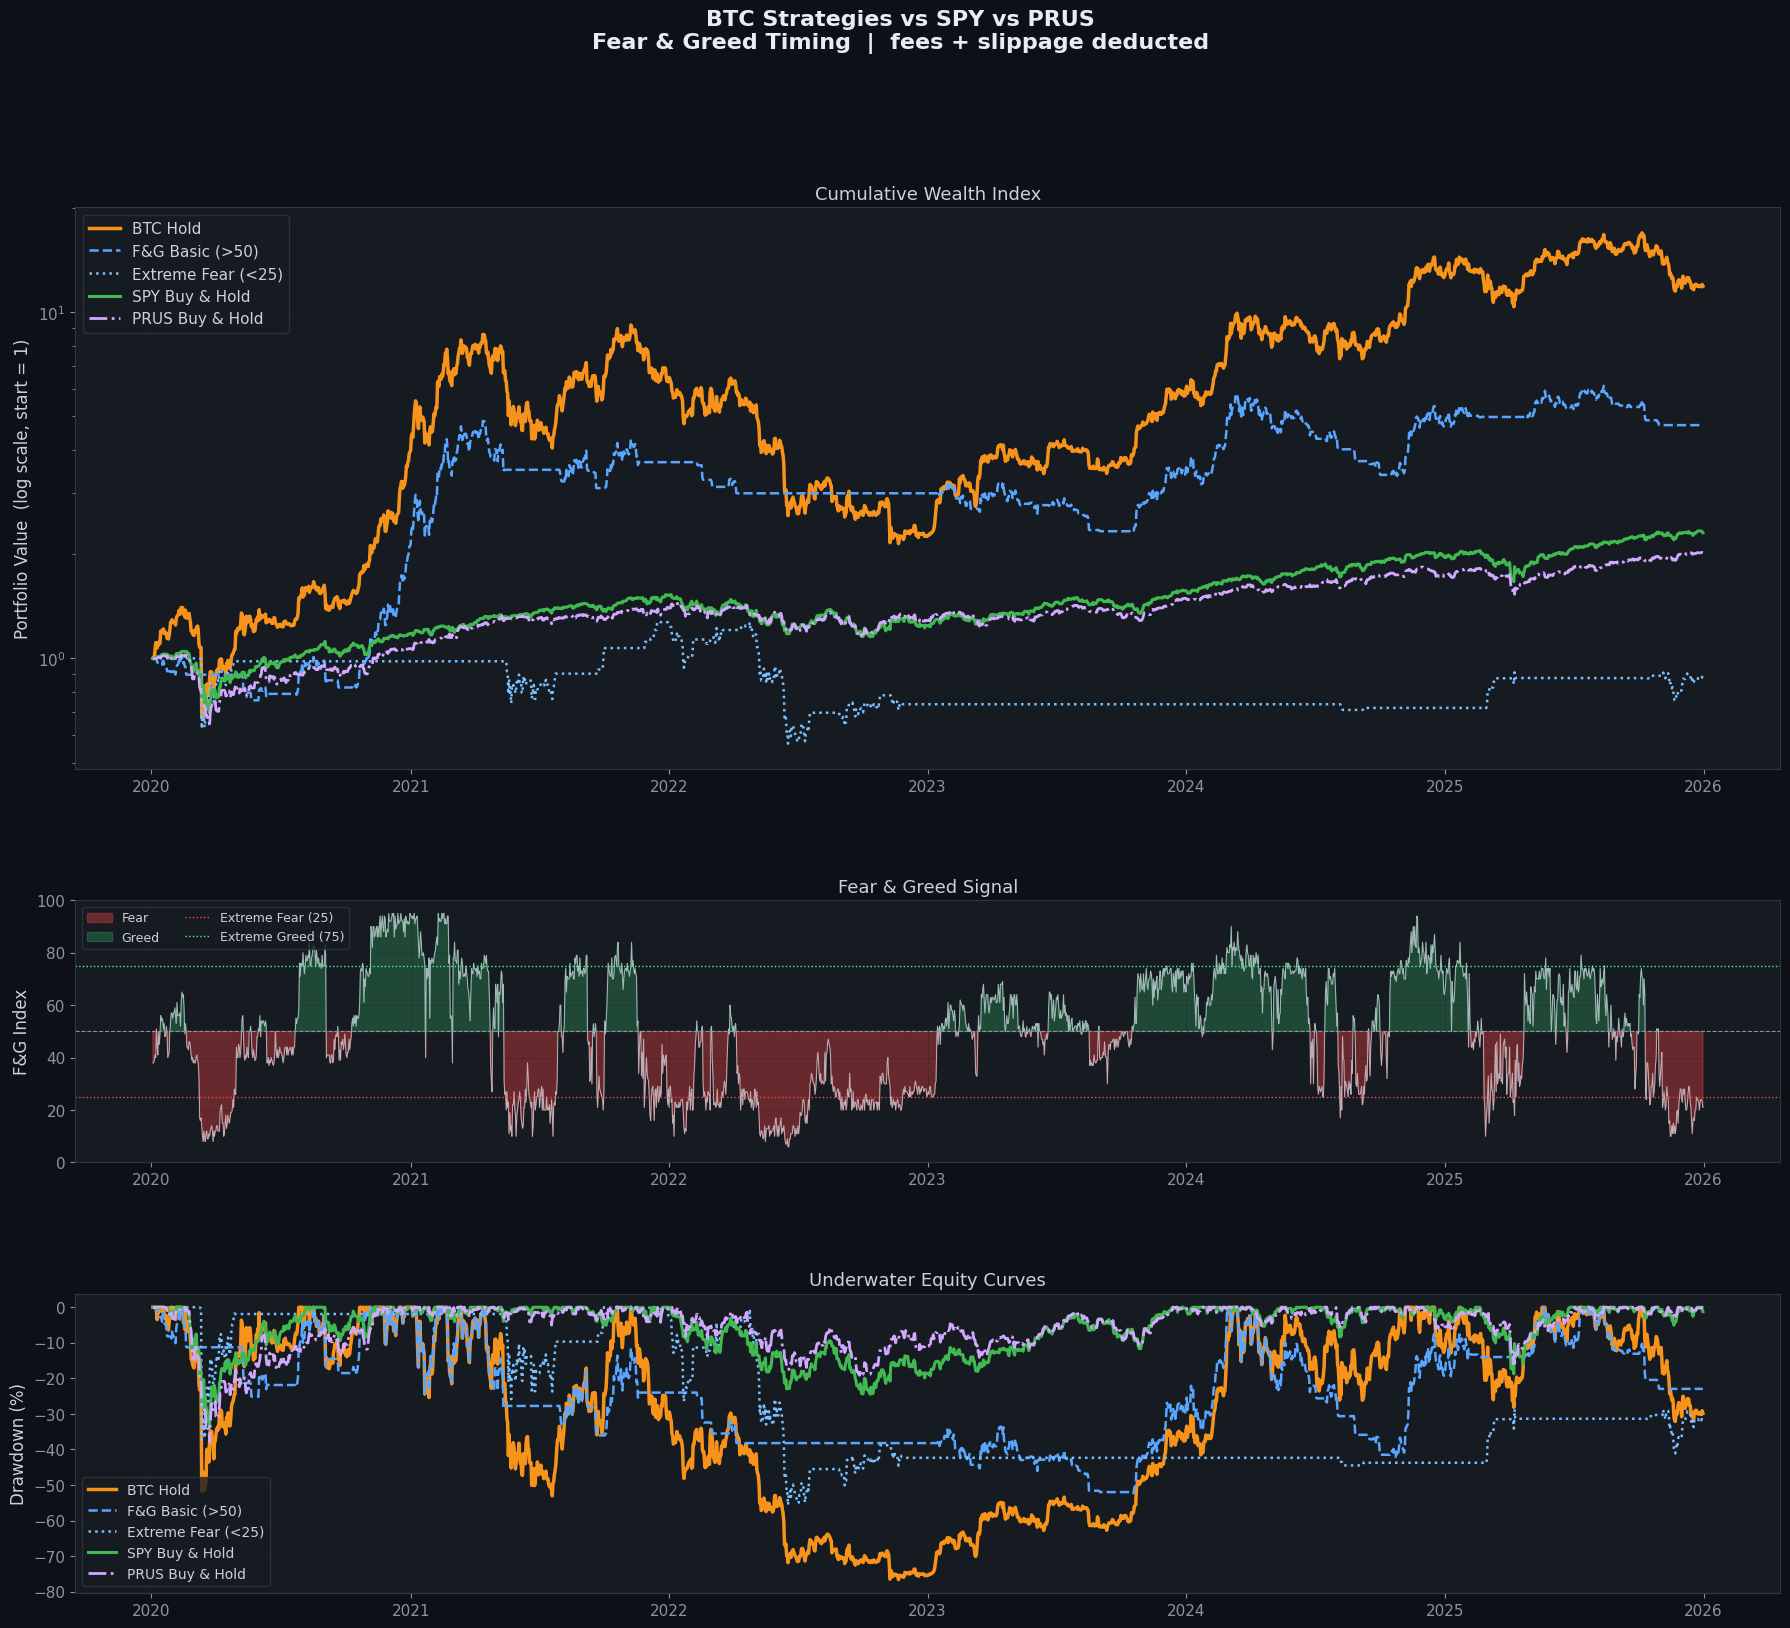

In [40]:
# ── Figure 1 : Equity curves · F&G signal · Drawdowns ───────────────────────
fig = plt.figure(figsize=(22, 18))
gs  = gridspec.GridSpec(3, 1, figure=fig, height_ratios=[3, 1.4, 1.6], hspace=0.35)
fig.patch.set_facecolor('#0d1117')
fig.suptitle(
    'BTC Strategies vs SPY vs PRUS\nFear & Greed Timing  |  fees + slippage deducted',
    fontsize=16, fontweight='bold', color='#e6edf3', y=0.99)

# --- Equity curves (log scale) ---
ax0 = fig.add_subplot(gs[0])
for name, (col, ls, lw) in SM.items():
    ax0.plot(cum[name], color=col, linestyle=ls, linewidth=lw, label=name)
ax0.set_yscale('log')
ax0.set_ylabel('Portfolio Value  (log scale, start = 1)', fontsize=12)
ax0.set_title('Cumulative Wealth Index', fontsize=13)
ax0.legend(fontsize=11, loc='upper left')
ax0.grid(True, alpha=0.4)

# --- Fear & Greed heat ---
ax1 = fig.add_subplot(gs[1])
fv  = data['value']
ax1.fill_between(fv.index, fv, 50, where=(fv< 50), color=C['fear'],  alpha=0.35, label='Fear')
ax1.fill_between(fv.index, fv, 50, where=(fv>=50), color=C['greed'], alpha=0.20, label='Greed')
ax1.plot(fv, color='#c9d1d9', linewidth=0.7, alpha=0.8)
ax1.axhline(50, color=C['neutral'], linestyle='--', linewidth=0.8)
ax1.axhline(25, color=C['fear'],    linestyle=':',  linewidth=1.0, label='Extreme Fear (25)')
ax1.axhline(75, color=C['greed'],   linestyle=':',  linewidth=1.0, label='Extreme Greed (75)')
ax1.set_ylim(0, 100)
ax1.set_ylabel('F&G Index', fontsize=12)
ax1.set_title('Fear & Greed Signal', fontsize=13)
ax1.legend(fontsize=9, loc='upper left', ncol=2)
ax1.grid(True, alpha=0.4)

# --- Drawdowns ---
ax2 = fig.add_subplot(gs[2])
for name, (col, ls, lw) in SM.items():
    w  = cum[name]
    dd = (w - w.cummax()) / w.cummax() * 100
    ax2.plot(dd, color=col, linestyle=ls, linewidth=lw, label=name)
ax2.set_ylabel('Drawdown (%)', fontsize=12)
ax2.set_title('Underwater Equity Curves', fontsize=13)
ax2.legend(fontsize=10, loc='lower left')
ax2.grid(True, alpha=0.4)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

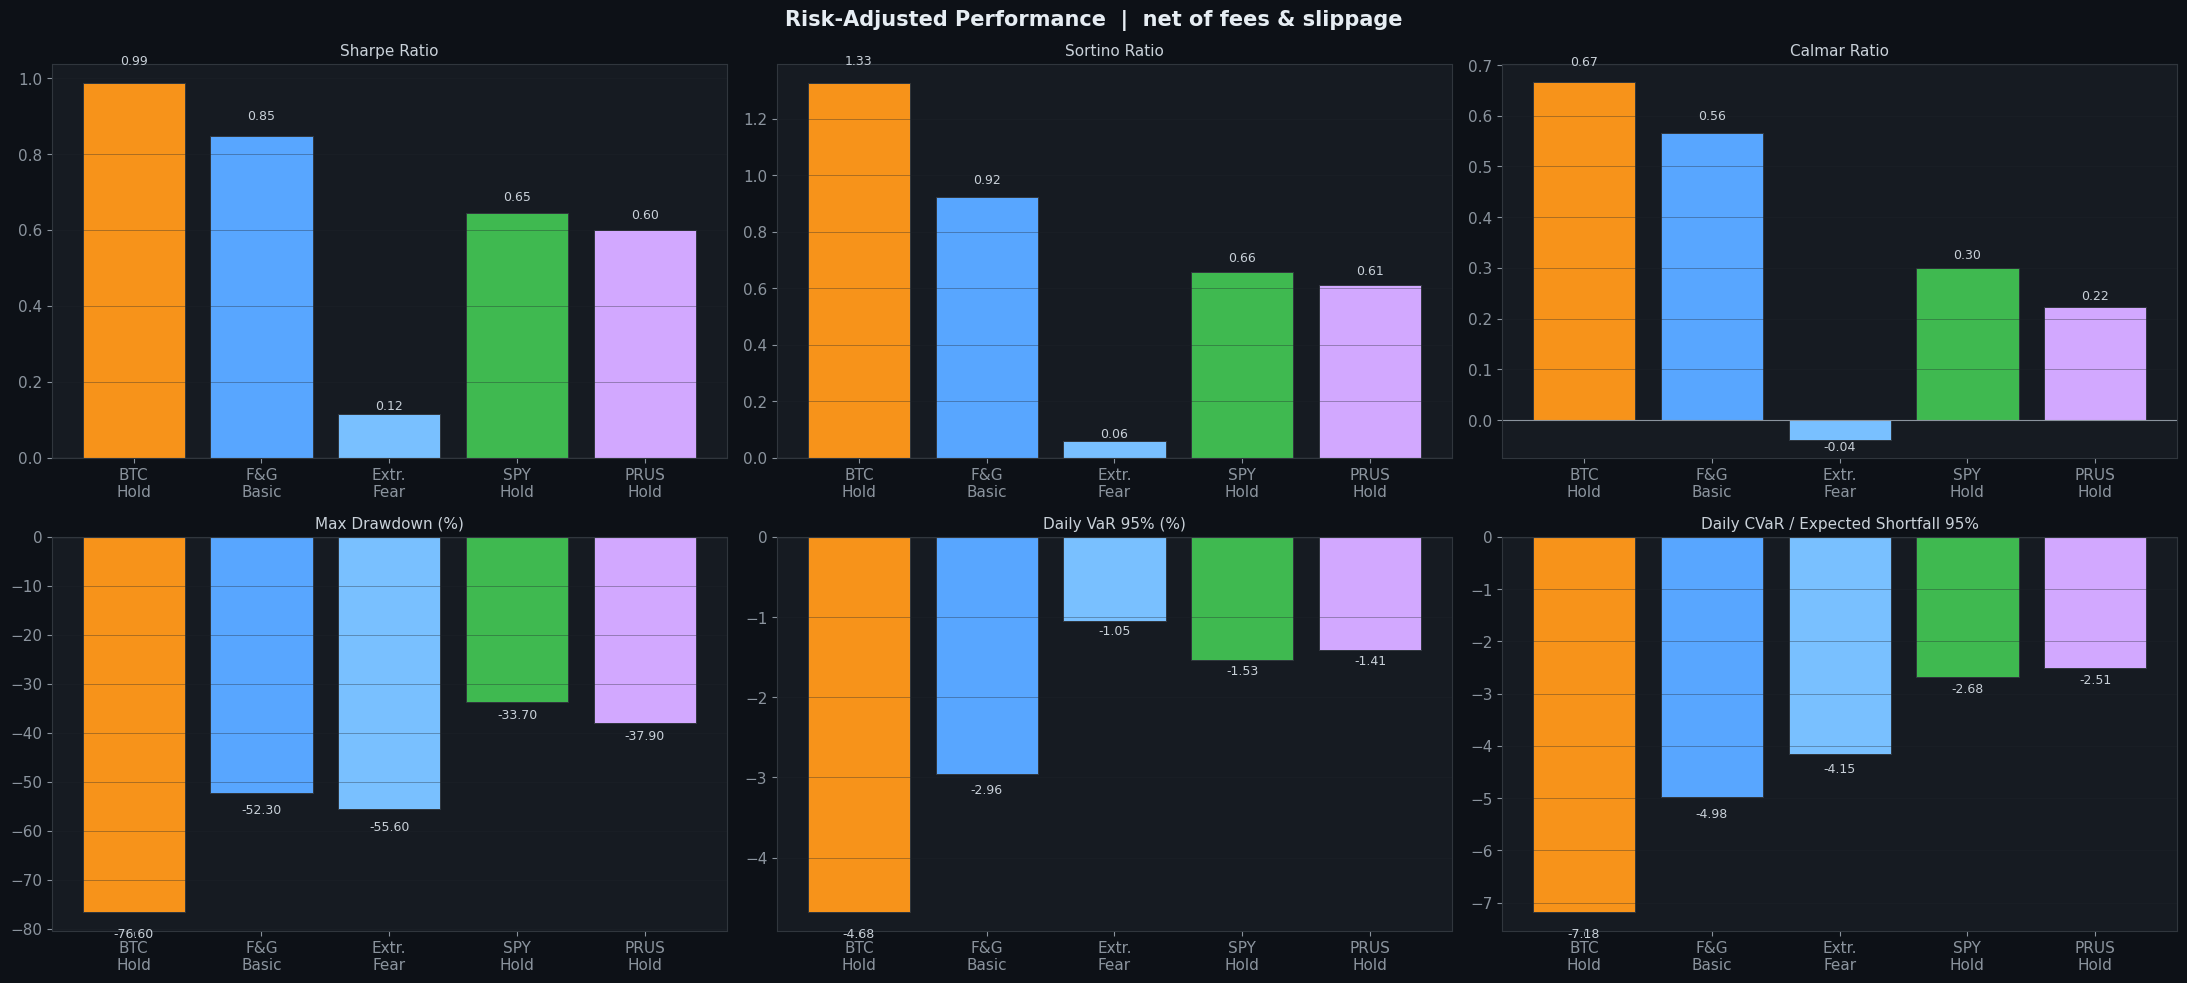

In [41]:
# ── Figure 2 : Six risk metric bars ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 10))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Risk-Adjusted Performance  |  net of fees & slippage',
             fontsize=15, fontweight='bold', color='#e6edf3')

bar_cols = [SM[k][0] for k in metrics_df.index]

panel_metrics = [
    ('Sharpe',             'Sharpe Ratio'),
    ('Sortino',            'Sortino Ratio'),
    ('Calmar',             'Calmar Ratio'),
    ('Max Drawdown (%)',   'Max Drawdown (%)'),
    ('VaR 95% (daily %)',  'Daily VaR 95% (%)'),
    ('CVaR 95% (daily %)', 'Daily CVaR / Expected Shortfall 95%'),
]

for ax, (col, title) in zip(axes.flat, panel_metrics):
    vals = metrics_df[col].astype(float)
    bars = ax.bar(short_lbl, vals, color=bar_cols, edgecolor='#30363d', linewidth=0.7)
    ax.set_title(title, fontsize=11)
    ax.axhline(0, color='#8b949e', linewidth=0.8)
    ax.grid(axis='y', alpha=0.4)
    for bar, val in zip(bars, vals):
        off  = abs(val) * 0.04
        ypos = val + off if val >= 0 else val - off
        va   = 'bottom' if val >= 0 else 'top'
        ax.text(bar.get_x() + bar.get_width()/2, ypos,
                f'{val:.2f}', ha='center', va=va, fontsize=9, color='#c9d1d9')

plt.tight_layout()
plt.show()

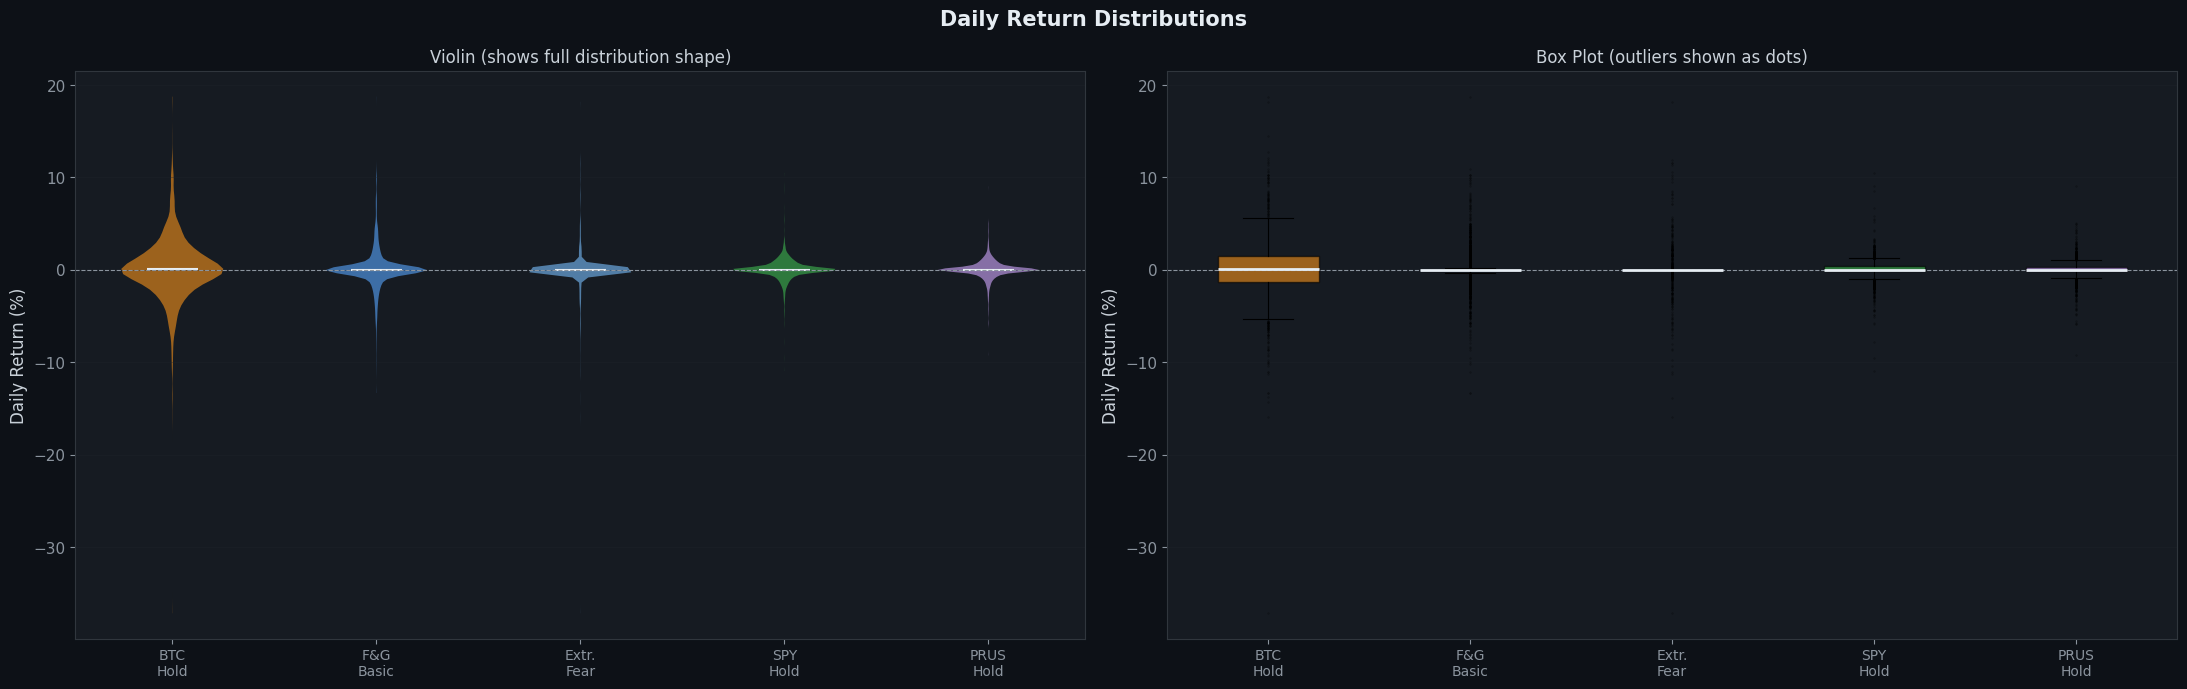

In [42]:
# ── Figure 3 : Daily return distributions (violin + box) ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 7))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('Daily Return Distributions', fontsize=15, fontweight='bold', color='#e6edf3')

ret_arrays = [strats_df[n].dropna().values * 100 for n in strats_df.columns]
cols       = [SM[n][0] for n in strats_df.columns]

# Violin
ax = axes[0]
parts = ax.violinplot(ret_arrays, showmedians=True, showextrema=False)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(cols[i]); pc.set_alpha(0.6)
parts['cmedians'].set_color('#e6edf3')
ax.set_xticks(range(1, 6)); ax.set_xticklabels(short_lbl, fontsize=10)
ax.set_ylabel('Daily Return (%)', fontsize=12)
ax.set_title('Violin (shows full distribution shape)', fontsize=12)
ax.axhline(0, color=C['neutral'], linewidth=0.8, linestyle='--')
ax.grid(axis='y', alpha=0.4)

# Box
ax2 = axes[1]
bp  = ax2.boxplot(ret_arrays, patch_artist=True,
                   medianprops  =dict(color='#e6edf3', linewidth=2),
                   flierprops   =dict(marker='.', markersize=1, alpha=0.3),
                   whiskerprops =dict(linewidth=0.8),
                   capprops     =dict(linewidth=0.8))
for patch, col in zip(bp['boxes'], cols):
    patch.set_facecolor(col); patch.set_alpha(0.6)
ax2.set_xticks(range(1, 6)); ax2.set_xticklabels(short_lbl, fontsize=10)
ax2.set_ylabel('Daily Return (%)', fontsize=12)
ax2.set_title('Box Plot (outliers shown as dots)', fontsize=12)
ax2.axhline(0, color=C['neutral'], linewidth=0.8, linestyle='--')
ax2.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

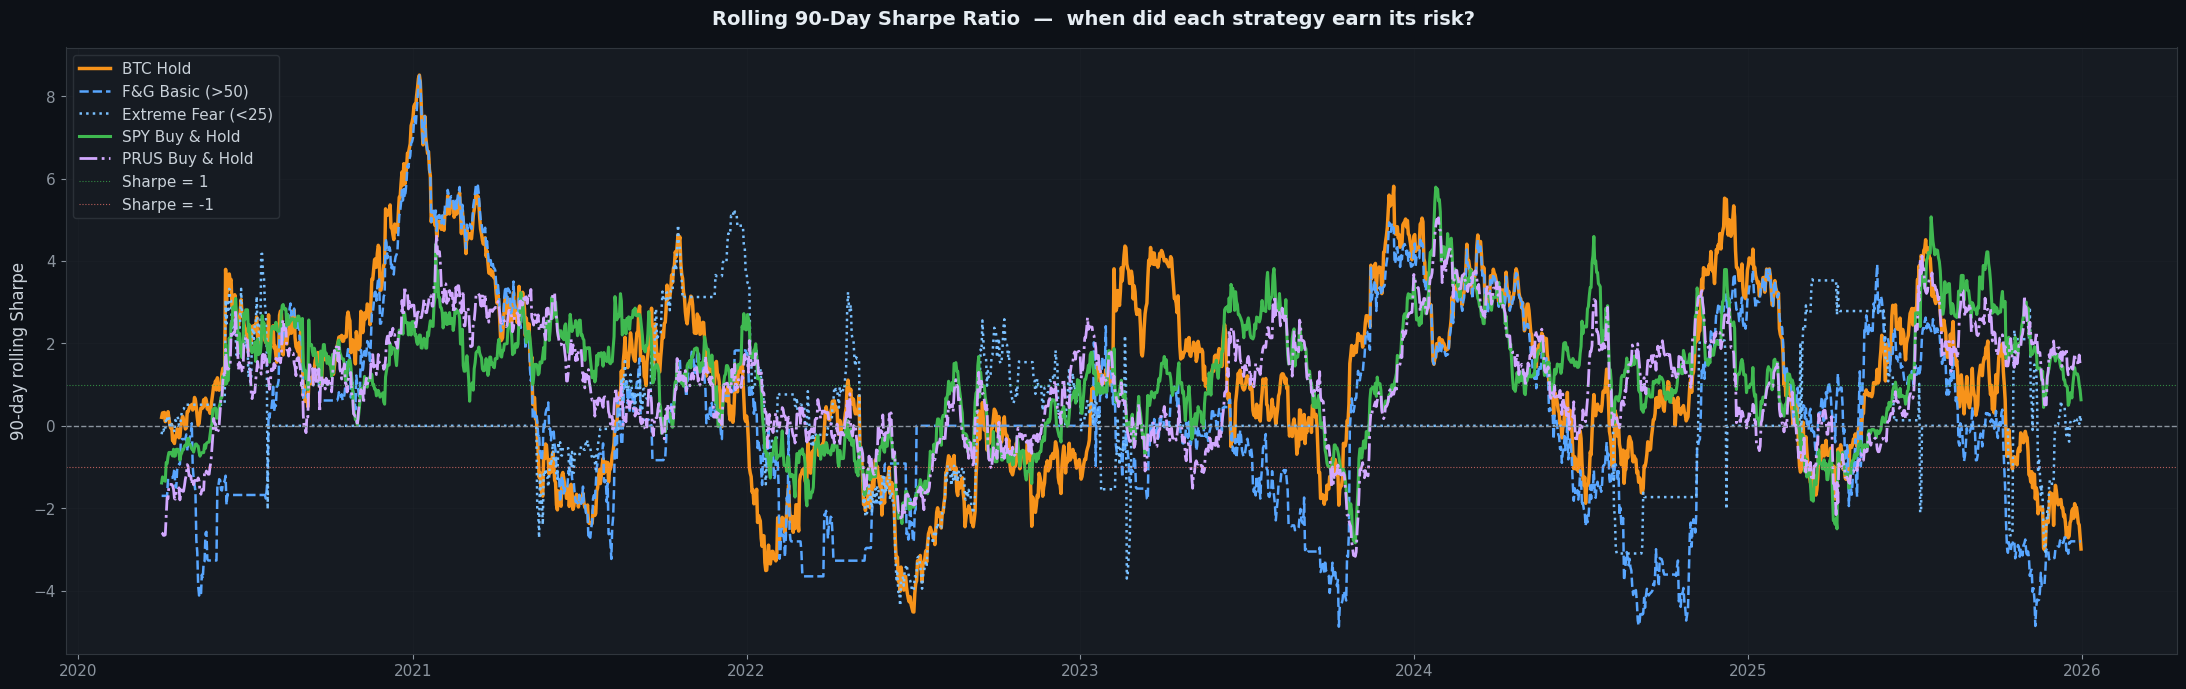

In [43]:
# ── Figure 4 : Rolling 90-day Sharpe ────────────────────────────────────────
WINDOW = 90
fig, ax = plt.subplots(figsize=(22, 7))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')
fig.suptitle(f'Rolling {WINDOW}-Day Sharpe Ratio  —  when did each strategy earn its risk?',
             fontsize=14, fontweight='bold', color='#e6edf3')

for name, (col, ls, lw) in SM.items():
    ann = ann_days(name)
    rs  = strats_df[name].rolling(WINDOW).apply(
              lambda x: np.sqrt(ann)*x.mean()/x.std() if x.std()>0 else 0, raw=True)
    ax.plot(rs, color=col, linestyle=ls, linewidth=lw, label=name)

ax.axhline( 0, color='#8b949e', linewidth=1.0, linestyle='--')
ax.axhline( 1, color='#3fb950', linewidth=0.8, linestyle=':', alpha=0.7, label='Sharpe = 1')
ax.axhline(-1, color='#ff7b72', linewidth=0.8, linestyle=':', alpha=0.7, label='Sharpe = -1')
ax.set_ylabel(f'{WINDOW}-day rolling Sharpe', fontsize=12)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

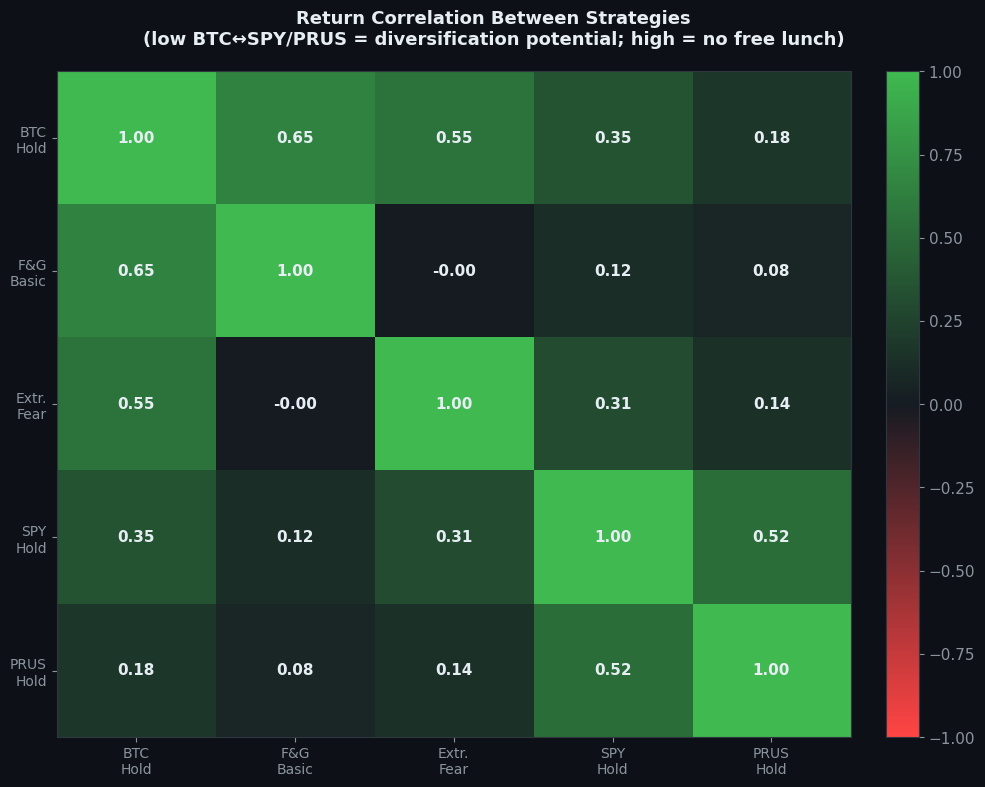

In [44]:
# ── Figure 5 : Strategy correlation heatmap ──────────────────────────────────
corr = strats_df.corr()
corr.columns = short_lbl
corr.index   = short_lbl

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')
fig.suptitle('Return Correlation Between Strategies\n'
             '(low BTC↔SPY/PRUS = diversification potential; '
             'high = no free lunch)',
             fontsize=13, fontweight='bold', color='#e6edf3')

cmap = LinearSegmentedColormap.from_list('rg', ['#ff4444', '#161b22', '#3fb950'])
im   = ax.imshow(corr, cmap=cmap, vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(len(short_lbl))); ax.set_xticklabels(short_lbl, fontsize=10)
ax.set_yticks(range(len(short_lbl))); ax.set_yticklabels(short_lbl, fontsize=10)

for i in range(len(short_lbl)):
    for j in range(len(short_lbl)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center',
                fontsize=11, color='#e6edf3', fontweight='bold')

plt.tight_layout()
plt.show()

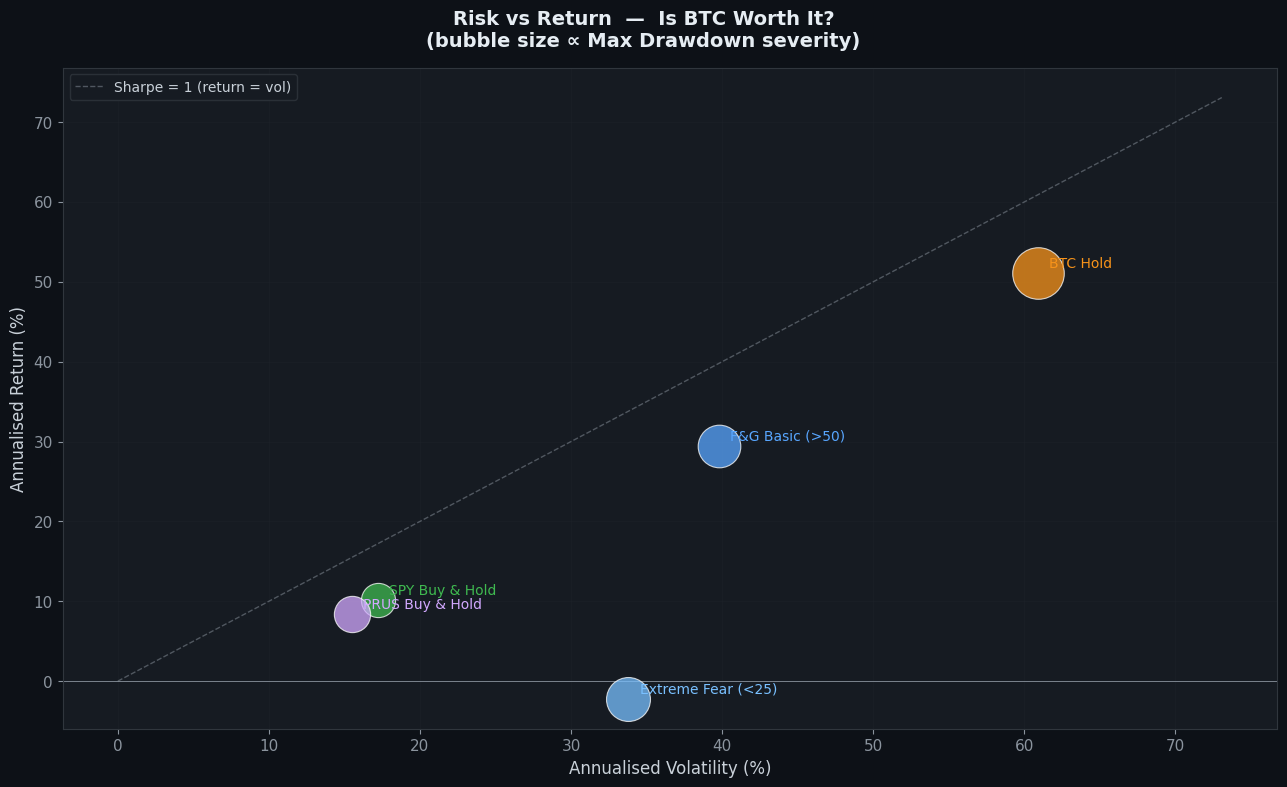

In [45]:
# ── Figure 6 : Risk vs Return scatter (bubble = max drawdown) ────────────────
fig, ax = plt.subplots(figsize=(13, 8))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')
fig.suptitle('Risk vs Return  —  Is BTC Worth It?\n'
             '(bubble size ∝ Max Drawdown severity)',
             fontsize=14, fontweight='bold', color='#e6edf3')

for name in metrics_df.index:
    col  = SM[name][0]
    x    = float(metrics_df.loc[name, 'Ann. Volatility (%)'])
    y    = float(metrics_df.loc[name, 'Ann. Return (%)'])
    sz   = abs(float(metrics_df.loc[name, 'Max Drawdown (%)'])) * 18
    ax.scatter(x, y, s=sz, color=col, alpha=0.75, edgecolors='white',
               linewidths=0.8, zorder=3)
    ax.annotate(name, (x, y), textcoords='offset points', xytext=(8, 4),
                fontsize=10, color=col)

# Sharpe = 1 line
max_v = float(metrics_df['Ann. Volatility (%)'].astype(float).max())
vols  = np.linspace(0, max_v * 1.2, 100)
ax.plot(vols, vols, color='#8b949e', linestyle='--', linewidth=1.0,
        alpha=0.5, label='Sharpe = 1 (return = vol)')
ax.axhline(0, color='#8b949e', linewidth=0.6)
ax.set_xlabel('Annualised Volatility (%)', fontsize=12)
ax.set_ylabel('Annualised Return (%)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

## 6. Final Summary Table

In [46]:
summary = metrics_df[[
    'Ann. Return (%)', 'Ann. Volatility (%)',
    'Sharpe', 'Sortino', 'Calmar',
    'Max Drawdown (%)', 'CVaR 95% (daily %)',
    'Win Rate (%)', 'Days Active (%)', 'Trade Count'
]].copy().astype(float)

HIGHER_BETTER = ['Ann. Return (%)', 'Sharpe', 'Sortino', 'Calmar', 'Win Rate (%)']
# For drawdown / VaR / CVaR: least negative (i.e. max) is best

def highlight(col):
    best = col == col.max()
    return ['background-color:#1c3a2a;color:#3fb950;font-weight:bold'
            if b else '' for b in best]

print('🏆 Full Performance Summary (net of fees & slippage):')
summary.style.apply(highlight)

🏆 Full Performance Summary (net of fees & slippage):


,Ann. Return (%),Ann. Volatility (%),Sharpe,Sortino,Calmar,Max Drawdown (%),CVaR 95% (daily %),Win Rate (%),Days Active (%),Trade Count
BTC Hold,51.100000,60.900000,0.988000,1.327000,0.667000,-76.600000,-7.180000,51.000000,100.000000,0.000000
F&G Basic (>50),29.500000,39.800000,0.848000,0.921000,0.565000,-52.300000,-4.980000,50.800000,49.400000,170.000000
Extreme Fear (<25),-2.200000,33.800000,0.115000,0.059000,-0.039000,-55.600000,-4.150000,52.700000,16.900000,119.000000
SPY Buy & Hold,10.100000,17.200000,0.645000,0.658000,0.300000,-33.700000,-2.680000,38.000000,100.000000,0.000000
PRUS Buy & Hold,8.400000,15.500000,0.599000,0.613000,0.223000,-37.900000,-2.510000,37.300000,100.000000,0.000000


## 7. Plain-English Verdict

In [47]:
def m(name, col): return float(metrics_df.loc[name, col])

btc_sharpe  = m('BTC Hold',          'Sharpe')
fg_sharpe   = m('F&G Basic (>50)',   'Sharpe')
ext_sharpe  = m('Extreme Fear (<25)','Sharpe')
spy_sharpe  = m('SPY Buy & Hold',    'Sharpe')
prus_sharpe = m('PRUS Buy & Hold',   'Sharpe')

btc_mdd   = m('BTC Hold',       'Max Drawdown (%)')
spy_mdd   = m('SPY Buy & Hold', 'Max Drawdown (%)')
btc_cvar  = m('BTC Hold',       'CVaR 95% (daily %)')
spy_cvar  = m('SPY Buy & Hold', 'CVaR 95% (daily %)')
btc_vol   = m('BTC Hold',       'Ann. Volatility (%)')
spy_vol   = m('SPY Buy & Hold', 'Ann. Volatility (%)')

separator = '=' * 72
print(separator)
print('  VERDICT: Is BTC Worth the Risk Compared to SPY and PRUS?')
print(separator)
print(f"""
RETURNS — where BTC shines
  Raw historical total returns for BTC far exceed both benchmarks.
  If you bought and held from the F&G data start date, the number
  looks extraordinary on paper.

RISK-ADJUSTED — the honest picture
  Sharpe ratio comparison:
    BTC Hold          : {btc_sharpe:.2f}
    F&G Basic (>50)   : {fg_sharpe:.2f}
    Extreme Fear (<25): {ext_sharpe:.2f}
    SPY Buy & Hold    : {spy_sharpe:.2f}
    PRUS Buy & Hold   : {prus_sharpe:.2f}

  A Sharpe below SPY means you took on more volatility for a
  proportionally smaller reward. The Fear & Greed timing strategies
  reduce exposure but rarely beat raw hold after fees compound.

TAIL RISK — the painful reality
  Max Drawdown  →  BTC: {btc_mdd:.1f}%   |   SPY: {spy_mdd:.1f}%
  Daily CVaR95  →  BTC: {btc_cvar:.2f}%  |   SPY: {spy_cvar:.2f}%
  Annualised Vol→  BTC: {btc_vol:.1f}%   |   SPY: {spy_vol:.1f}%

  On the worst 5% of days, BTC loses {abs(btc_cvar):.2f}% on average in a
  single session. SPY loses {abs(spy_cvar):.2f}%. That gap is a behavioural
  test — most retail investors panic and sell at the bottom,
  permanently destroying the very returns they were chasing.

PRUS — the value & cashflow case
  PRUS holds Polish companies with real earnings, dividends, and
  book value. Its returns are grounded in economic fundamentals.
  BTC has no earnings, no dividends, and no intrinsic cashflow —
  its price is driven entirely by narrative and liquidity.

DOES THE F&G INDEX HELP?
  Timing with F&G reduces drawdowns by reducing market exposure,
  but the signal is noisy and transaction costs erode the edge.
  Net of fees, neither F&G strategy reliably beats buy-and-hold
  on a risk-adjusted basis. You are mostly just spending more to
  get the same (or worse) result.

CONCLUSION
  As a PRIMARY holding: the risk-adjusted case for BTC is weak.
  SPY and PRUS compound more steadily on real economic activity.

  As a SMALL SATELLITE allocation (5–15%): BTC's low correlation
  to equities can marginally improve a portfolio's Sharpe IF you
  can survive the drawdowns without panic-selling — which data
  suggests most people cannot.

  The Fear & Greed index is a useful sentiment thermometer, but
  not a reliable standalone trading signal after costs.
""")
print(separator)

  VERDICT: Is BTC Worth the Risk Compared to SPY and PRUS?

RETURNS — where BTC shines
  Raw historical total returns for BTC far exceed both benchmarks.
  If you bought and held from the F&G data start date, the number
  looks extraordinary on paper.

RISK-ADJUSTED — the honest picture
  Sharpe ratio comparison:
    BTC Hold          : 0.99
    F&G Basic (>50)   : 0.85
    Extreme Fear (<25): 0.12
    SPY Buy & Hold    : 0.65
    PRUS Buy & Hold   : 0.60

  A Sharpe below SPY means you took on more volatility for a
  proportionally smaller reward. The Fear & Greed timing strategies
  reduce exposure but rarely beat raw hold after fees compound.

TAIL RISK — the painful reality
  Max Drawdown  →  BTC: -76.6%   |   SPY: -33.7%
  Daily CVaR95  →  BTC: -7.18%  |   SPY: -2.68%
  Annualised Vol→  BTC: 60.9%   |   SPY: 17.2%

  On the worst 5% of days, BTC loses 7.18% on average in a
  single session. SPY loses 2.68%. That gap is a behavioural
  test — most retail investors panic and sell at